👥 Notebook 05: Customer RFM Segmentation & Cohort Analysis

Questo notebook finale si concentra sull'analisi approfondita del comportamento dei clienti:

1. Analisi RFM (Recency, Frequency, Monetary): Calcolo e segmentazione dei clienti in fasce di valore.

1. Customer Profiling: Identificazione dei clienti top (Champions), dei clienti a rischio (At Risk) e di quelli persi (Lost).

1. Cohort Analysis: Tracciamento dei gruppi di acquisto nel tempo basati sulla data del primo ordine.

1. Retention Rate: Calcolo percentuale del tasso di mantenimento dei clienti mese per mese.

### 1. Importazione Librerie e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CLEANED_DATA_PATH = '../data/superstore_cleaned.csv'
df = pd.read_csv(CLEANED_DATA_PATH)

# Assicuriamoci che i campi data siano riconosciuti correttamente
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f"Dataset caricato: {df.shape[0]} righe. Totalelienti unici: {df['Customer ID'].nunique()}")

Dataset caricato: 9800 righe. Totalelienti unici: 793


### 2. Calcolo delle Metriche RFM per Cliente

In [2]:
# Definizione della data di riferimento (1 giorno dopo l'ultimo ordine registrato nel dataset)
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)

# Aggregazione per singolo cliente
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,  # Recency (giorni dall'ultimo ordine)
    'Order ID': 'nunique',                                   # Frequency (numero ordini unici)
    'Sales': 'sum'                                           # Monetary (totale speso)
}).reset_index()

# Rinominiamo le colonne
rfm.columns = ['Customer_ID', 'Recency_Days', 'Frequency', 'Monetary']

display(rfm.head())
print("\nStatistiche descrittive delle metriche RFM:")
display(rfm[['Recency_Days', 'Frequency', 'Monetary']].describe().round(2))


,Customer_ID,Recency_Days,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156



Statistiche descrittive delle metriche RFM:


,Recency_Days,Frequency,Monetary
count,793.00,793.00,793.00
mean,149.29,6.21,2851.87
std,187.08,2.53,2620.67
min,1.00,1.00,4.83
25%,31.00,4.00,1081.47
50%,76.00,6.00,2215.00
75%,185.00,8.00,3670.26
max,1166.00,17.00,25043.05


### 3. Assegnazione dei Punteggi e Segmentazione Clienti

--- DISTRIBUZIONE DEI SEGMENTI CLIENTI ---


,Segmento,Numero Clienti,% Totale
0,Loyal Customers,198,24.97
1,At Risk,161,20.30
2,Champions,131,16.52
3,Lost,131,16.52
4,Can't Lose Them,104,13.11
5,Promising / New,68,8.58


C:\Users\ameli\AppData\Local\Temp\ipykernel_19500\806818633.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='% Totale', y='Segmento', palette='Blues_r')


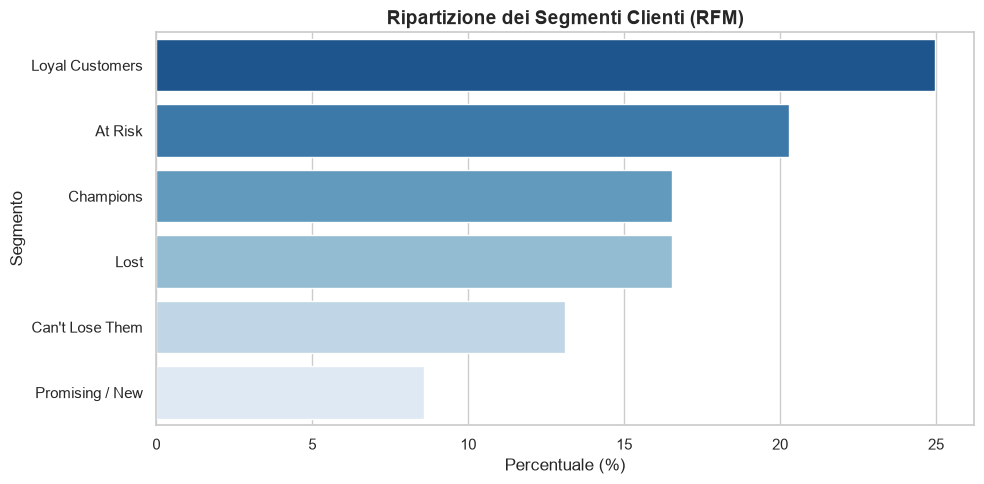

In [4]:
# Assegnazione punteggi da 1 a 4 tramite quantili (pd.qcut)
# Nota: Per Recency un numero di giorni inferiore indica un punteggio più ALTO (migliore)
rfm['R_Score'] = pd.qcut(rfm['Recency_Days'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Creazione del codice combinato RFM (es. '444', '111')
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# Definizione delle logiche di segmentazione aziendale
def assign_segment(row):
    score = row['RFM_Score']
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    
    if r == 4 and f >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Promising / New'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 1 and f >= 2:
        return "Can't Lose Them"
    else:
        return 'Lost'

rfm['Customer_Segment'] = rfm.apply(assign_segment, axis=1)

print("--- DISTRIBUZIONE DEI SEGMENTI CLIENTI ---")
segment_counts = rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Segmento', 'Numero Clienti']
segment_counts['% Totale'] = (segment_counts['Numero Clienti'] / len(rfm) * 100).round(2)
display(segment_counts)

# Visualizzazione grafica dei segmenti
plt.figure(figsize=(10, 5))
sns.barplot(data=segment_counts, x='% Totale', y='Segmento', palette='Blues_r')
plt.title("Ripartizione dei Segmenti Clienti (RFM)", fontsize=14, fontweight='bold')
plt.xlabel("Percentuale (%)")
plt.tight_layout()
plt.show()

### 4. Cohort Analysis (Analisi di Coorte delle Vendite)

In [5]:
# A. Estrazione del Mese di Acquisto e del Mese della Coorte (Primo Acquisto del Cliente)
df['Order_Month'] = df['Order Date'].dt.to_period('M')
df['Cohort_Month'] = df.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('M')

# B. Calcolo dell'indice della Coorte (Mesi trascorsi dal primo ordine: 0, 1, 2, ...)
def get_cohort_index(df):
    year_diff = df['Order_Month'].dt.year - df['Cohort_Month'].dt.year
    month_diff = df['Order_Month'].dt.month - df['Cohort_Month'].dt.month
    return year_diff * 12 + month_diff

df['Cohort_Index'] = get_cohort_index(df)

# C. Creazione Pivot Table per contare i clienti unici attivi per ogni coorte
cohort_data = df.groupby(['Cohort_Month', 'Cohort_Index'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='Cohort_Month', columns='Cohort_Index', values='Customer ID')

print("--- TABELLA NUMERO CLIENTI PER COORTE ---")
display(cohort_pivot.head(12))


--- TABELLA NUMERO CLIENTI PER COORTE ---


Cohort_Index,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2015-01,30.0,2.0,NaN,2.0,2.0,NaN,2.0,3.0,3.0,3.0,...,5.0,3.0,5.0,3.0,1.0,2.0,8.0,9.0,10.0,6.0
2015-02,25.0,4.0,2.0,1.0,NaN,2.0,2.0,4.0,3.0,3.0,...,2.0,2.0,6.0,2.0,3.0,4.0,6.0,6.0,3.0,NaN
2015-03,63.0,4.0,2.0,8.0,7.0,NaN,7.0,5.0,6.0,6.0,...,13.0,9.0,12.0,6.0,19.0,6.0,18.0,14.0,NaN,NaN
2015-04,53.0,6.0,1.0,3.0,2.0,8.0,5.0,9.0,8.0,1.0,...,5.0,7.0,7.0,14.0,8.0,12.0,12.0,NaN,NaN,NaN
2015-05,55.0,5.0,5.0,4.0,10.0,2.0,11.0,10.0,4.0,3.0,...,7.0,5.0,16.0,7.0,17.0,9.0,NaN,NaN,NaN,NaN
2015-06,47.0,2.0,1.0,4.0,2.0,9.0,8.0,1.0,4.0,6.0,...,3.0,12.0,7.0,15.0,11.0,NaN,NaN,NaN,NaN,NaN
2015-07,43.0,6.0,5.0,NaN,5.0,8.0,2.0,NaN,8.0,2.0,...,11.0,8.0,13.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2015-08,50.0,8.0,3.0,11.0,5.0,3.0,4.0,2.0,5.0,3.0,...,12.0,11.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-09,68.0,9.0,8.0,11.0,1.0,2.0,8.0,10.0,9.0,2.0,...,16.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5. Retention Rate Heatmap

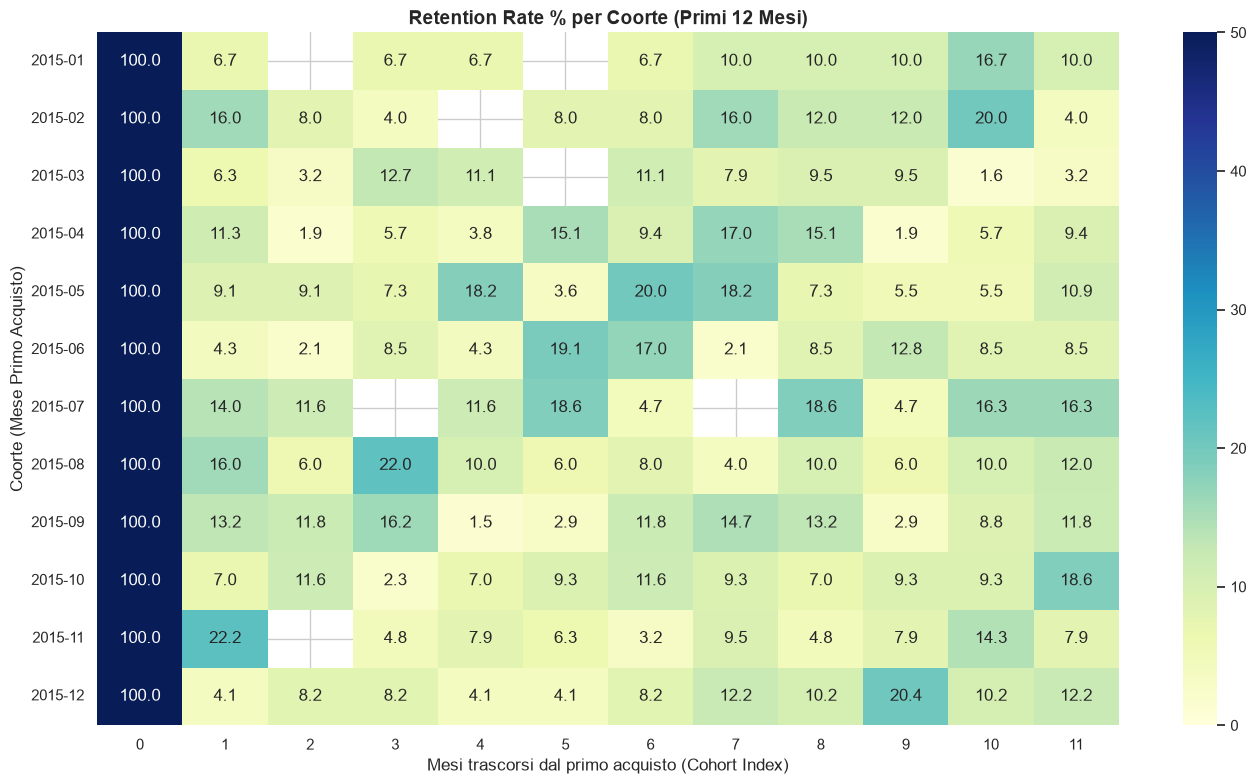

In [6]:
# Calcolo della percentuale di Retention (relativa alla dimensione iniziale Mese 0)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

# Visualizzazione Heatmap della Retention per le prime 12 coorti
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix.iloc[:12, :12], annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=50)
plt.title("Retention Rate % per Coorte (Primi 12 Mesi)", fontsize=14, fontweight='bold')
plt.xlabel("Mesi trascorsi dal primo acquisto (Cohort Index)")
plt.ylabel("Coorte (Mese Primo Acquisto)")
plt.tight_layout()
plt.show()

### 6. Esportazione del Profilo Clienti

In [7]:
# Salviamo i risultati dell'analisi RFM per integrazioni future o report di marketing
rfm.to_csv('../data/customer_rfm_segments.csv', index=False)
print("Analisi RFM e Coorte completata con successo! Dati esportati.")

Analisi RFM e Coorte completata con successo! Dati esportati.
